# Breast Cancer Dual & Triple Target Analysis

Identifies the best 2- and 3-gene therapeutic target combinations for TCGA Breast Invasive Carcinoma.
Compares tumor vs normal tissue expression. Uses SMOTE (applied inside each CV fold) to balance the tumor/normal class imbalance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from itertools import combinations
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 1. Load, clean & map gene names

In [2]:
df = pd.read_csv('denseDataOnlyDownload-2.tsv', sep='\t')

ensembl_map = {
    'ENSG00000082175.15': 'PGR',
    'ENSG00000141736.14': 'ERBB2',
    'ENSG00000087586.18': 'SLAMF7',
    'ENSG00000171862.11': 'PTEN',
    'ENSG00000146648.19': 'EGFR',
    'ENSG00000103855.18': 'CD276',
    'ENSG00000090339.9':  'ICAM1'
}
df = df.rename(columns=ensembl_map)
df = df.rename(columns={'sample_type.samples':'sample_type','primary_diagnosis.diagnoses':'primary_diagnosis'})
GENES = list(ensembl_map.values())

# Remove nulls
before = len(df)
df = df.dropna(subset=GENES + ['sample_type'])
print(f'Removed {before-len(df)} rows with nulls → {len(df)} samples remaining')
print(f'Sample types:\n{df["sample_type"].value_counts()}')

Removed 31 rows with nulls → 1226 samples remaining
Sample types:
sample_type
Primary Tumor          1106
Solid Tissue Normal     113
Metastatic                7
Name: count, dtype: int64


## 2. Split tumor vs normal

In [3]:
tumor  = df[df['sample_type'].isin(['Primary Tumor','Metastatic'])].copy()
normal = df[df['sample_type'] == 'Solid Tissue Normal'].copy()
combined = pd.concat([tumor, normal], ignore_index=True)
combined['label'] = (combined['sample_type'].isin(['Primary Tumor','Metastatic'])).astype(int)
print(f'Tumor samples:  {len(tumor)}')
print(f'Normal samples: {len(normal)}')

Tumor samples:  1113
Normal samples: 113


## 3. Tumor vs normal expression comparison

Gene         Tumor mean  Normal mean  Fold diff      p-value
----------------------------------------------------------
PGR               2.225        2.557      0.870     4.28e-03 **
ERBB2             5.366        4.335      1.238     5.36e-14 ***
SLAMF7            3.094        1.075      2.879     1.97e-62 ***
PTEN              3.446        4.105      0.840     1.00e-32 ***
EGFR              1.836        4.216      0.435     1.23e-58 ***
CD276             4.651        3.858      1.206     6.07e-39 ***
ICAM1             3.355        3.165      1.060     3.32e-02 *


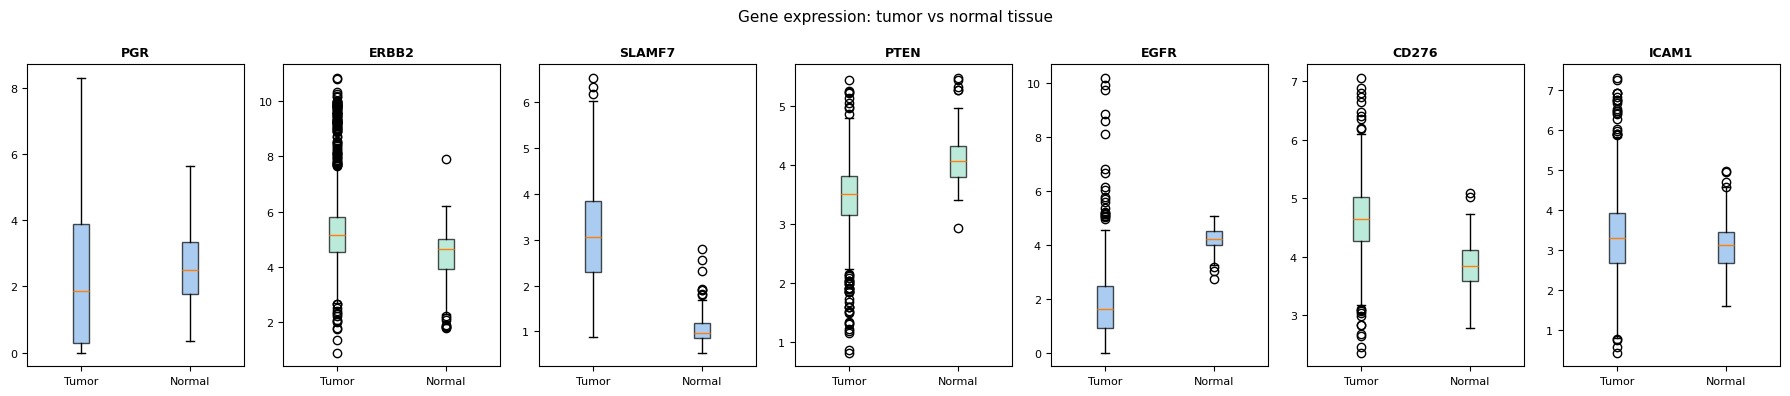

In [4]:
print(f'{"Gene":<10} {"Tumor mean":>12} {"Normal mean":>12} {"Fold diff":>10} {"p-value":>12}')
print('-'*58)
for g in GENES:
    t_vals, n_vals = tumor[g].values, normal[g].values
    fold = t_vals.mean() / n_vals.mean() if n_vals.mean() != 0 else np.nan
    _, p = stats.mannwhitneyu(t_vals, n_vals, alternative='two-sided')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f'{g:<10} {t_vals.mean():>12.3f} {n_vals.mean():>12.3f} {fold:>10.3f} {p:>12.2e} {sig}')

# Boxplots
fig, axes = plt.subplots(1, len(GENES), figsize=(18, 4))
for i, g in enumerate(GENES):
    data = [tumor[g].values, normal[g].values]
    axes[i].boxplot(data, labels=['Tumor','Normal'], patch_artist=True,
                    boxprops=dict(facecolor='#85B7EB' if i%2==0 else '#9FE1CB', alpha=0.7))
    axes[i].set_title(g, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=8)
plt.suptitle('Gene expression: tumor vs normal tissue', fontsize=11)
plt.tight_layout()
plt.show()

## 4. SMOTE — balance normal samples inside each CV fold

Normal tissue samples (n=113) are heavily outnumbered by tumor samples (n=1,113). SMOTE generates synthetic normal samples by interpolating between real normal neighbors in feature space. **Critically, SMOTE is applied only to training folds to prevent data leakage.**

In [5]:
def smote(X_min, n_synthetic, k=5, random_state=42):
    """Minimal SMOTE: oversample minority class via nearest-neighbor interpolation."""
    rng = np.random.default_rng(random_state)
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    _, indices = nn.kneighbors(X_min)
    synthetic = []
    n = len(X_min)
    for _ in range(n_synthetic):
        idx = rng.integers(0, n)
        neighbor = indices[idx, rng.integers(1, k+1)]
        lam = rng.random()
        synthetic.append(X_min[idx] + lam * (X_min[neighbor] - X_min[idx]))
    return np.array(synthetic)

X_orig = combined[GENES].values
y_orig = combined['label'].values

# Demonstrate SMOTE on full set for EDA only
X_normal_only = X_orig[y_orig==0]
n_needed = int(y_orig.sum()) - int((y_orig==0).sum())
synth = smote(X_normal_only, n_needed)
X_sm = np.vstack([X_orig, synth])
y_sm = np.concatenate([y_orig, np.zeros(n_needed, dtype=int)])
print(f'Original:   tumor={y_orig.sum()}  normal={(y_orig==0).sum()}')
print(f'Post-SMOTE: tumor={y_sm.sum()}  normal={(y_sm==0).sum()}')
print(f'Synthetic normal samples added: {n_needed}')

Original:   tumor=1113  normal=113
Post-SMOTE: tumor=1113  normal=1113
Synthetic normal samples added: 1000


coverage scoring

In [11]:
df_sm = pd.DataFrame(X_sm, columns=GENES)
df_sm['label'] = y_sm
tumor_sm  = df_sm[df_sm['label']==1]
normal_sm = df_sm[df_sm['label']==0]


scores_2, scores_3 = [], []
for combo in combinations(GENES, 2):
    t = combo_score(combo, tumor_sm2)
    n = combo_score(combo, normal_sm2)
    scores_2.append({'label':' + '.join(combo),'tumor':t,'normal':n,'spec':t-n})
for combo in combinations(GENES, 3):
    t = combo_score(combo, tumor_sm2)
    n = combo_score(combo, normal_sm2)
    scores_3.append({'label':' + '.join(combo),'tumor':t,'normal':n,'spec':t-n})

scores_2.sort(key=lambda x:(-x['spec'],-x['tumor']))
scores_3.sort(key=lambda x:(-x['spec'],-x['tumor']))

print('Top 10 dual targets (ranked by tumor specificity):')
print(f"  {'Combo':<22}  {'Tumor':>7}  {'Normal':>7}  {'Specificity':>12}")
for r in scores_2[:10]:
    print(f"  {r['label']:<22}  {r['tumor']:>7.1%}  {r['normal']:>7.1%}  {r['spec']:>+12.1%}")
print()
print('Top 10 triple targets (ranked by tumor specificity):')
print(f"  {'Combo':<34}  {'Tumor':>7}  {'Normal':>7}  {'Specificity':>12}")
for r in scores_3[:10]:
    print(f"  {r['label']:<34}  {r['tumor']:>7.1%}  {r['normal']:>7.1%}  {r['spec']:>+12.1%}")

Top 10 dual targets (ranked by tumor specificity):
  Combo                     Tumor   Normal   Specificity
  SLAMF7 + CD276            43.3%     0.1%        +43.2%
  ERBB2 + SLAMF7            43.6%     2.2%        +41.4%
  ERBB2 + CD276             42.9%     2.2%        +40.7%
  PGR + SLAMF7              48.2%    11.1%        +37.1%
  ERBB2 + ICAM1             45.7%     9.3%        +36.4%
  PGR + CD276               46.6%    11.1%        +35.5%
  CD276 + ICAM1             42.4%     7.3%        +35.1%
  SLAMF7 + ICAM1            41.3%     7.2%        +34.1%
  PGR + ERBB2               45.3%    13.2%        +32.1%
  PGR + ICAM1               46.4%    17.6%        +28.8%

Top 10 triple targets (ranked by tumor specificity):
  Combo                                 Tumor   Normal   Specificity
  ERBB2 + SLAMF7 + CD276                56.6%     2.2%        +54.4%
  PGR + SLAMF7 + CD276                  63.3%    11.1%        +52.1%
  PGR + ERBB2 + SLAMF7                  62.4%    13.2%       

## 6. Coverage plot — best combos

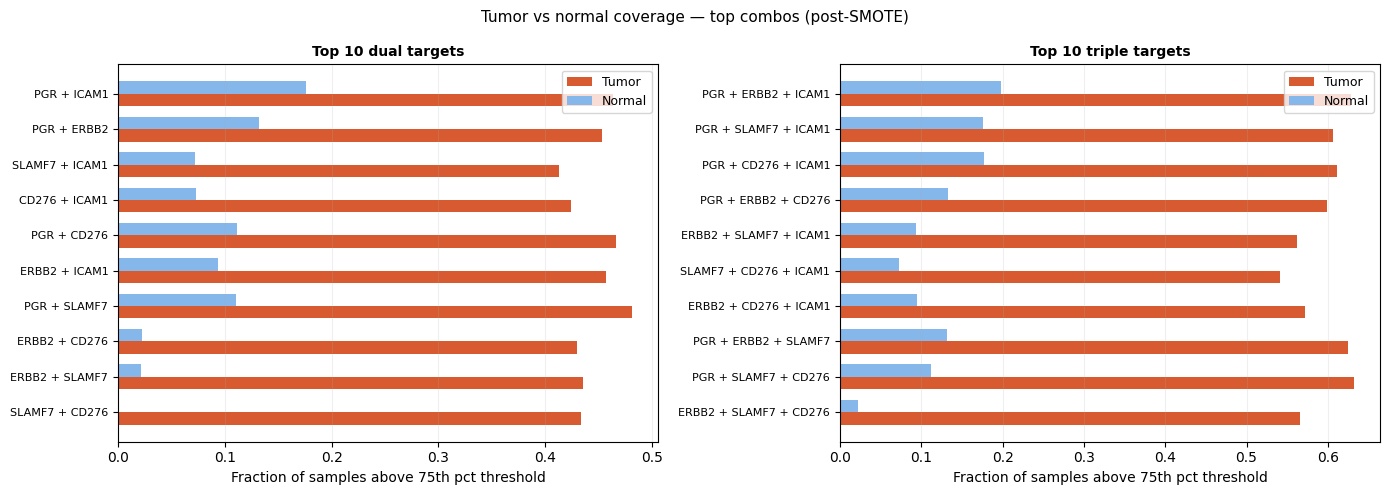

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, title in [
    (axes[0], scores_2[:10], 'Top 10 dual targets'),
    (axes[1], scores_3[:10], 'Top 10 triple targets')
]:
    labels = [r['label'] for r in scores]
    tumor_vals  = [r['tumor']  for r in scores]
    normal_vals = [r['normal'] for r in scores]
    x = np.arange(len(labels))
    w = 0.35
    ax.barh(x-w/2, tumor_vals,  w, label='Tumor',  color='#D85A30')
    ax.barh(x+w/2, normal_vals, w, label='Normal', color='#85B7EB')
    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Fraction of samples above 75th pct threshold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.2)
plt.suptitle('Tumor vs normal coverage — top combos (post-SMOTE)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Model comparison — RF, DT, LR (SMOTE inside each fold)

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
top2 = [tuple(r['label'].split(' + ')) for r in scores_2[:5]]
top3 = [tuple(r['label'].split(' + ')) for r in scores_3[:5]]

all_results = []
for combos, size in [(top2,'2-gene'), (top3,'3-gene')]:
    print(f'{size} combos:')
    for combo in combos:
        Xc = combined[list(combo)].values
        yc = combined['label'].values
        rf_s, dt_s, lr_s = [], [], []
        for tr, te in cv.split(Xc, yc):
            X_tr, X_te = Xc[tr], Xc[te]
            y_tr, y_te = yc[tr], yc[te]
            X_min = X_tr[y_tr==0]
            n_add = int(y_tr.sum()) - len(X_min)
            if n_add > 0 and len(X_min) > 5:
                s = smote(X_min, n_add, k=min(5,len(X_min)-1))
                X_tr = np.vstack([X_tr, s])
                y_tr = np.concatenate([y_tr, np.zeros(n_add,dtype=int)])
            rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
            rf.fit(X_tr, y_tr); rf_s.append(f1_score(y_te, rf.predict(X_te)))
            dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
            dt.fit(X_tr, y_tr); dt_s.append(f1_score(y_te, dt.predict(X_te)))
            pipe = Pipeline([('sc',StandardScaler()),('lr',LogisticRegression(max_iter=300,random_state=42,class_weight='balanced'))])
            pipe.fit(X_tr, y_tr); lr_s.append(f1_score(y_te, pipe.predict(X_te)))
        rf_f1,dt_f1,lr_f1 = np.mean(rf_s),np.mean(dt_s),np.mean(lr_s)
        print(f'  {" + ".join(combo):<34}  RF={rf_f1:.4f}  DT={dt_f1:.4f}  LR={lr_f1:.4f}')
        all_results.append({'combo':' + '.join(combo),'size':size,'RF':rf_f1,'DT':dt_f1,'LR':lr_f1})

2-gene combos:
  SLAMF7 + CD276                      RF=0.9646  DT=0.9642  LR=0.9561
  ERBB2 + SLAMF7                      RF=0.9675  DT=0.9595  LR=0.9572
  ERBB2 + CD276                       RF=0.8878  DT=0.8750  LR=0.8871
  PGR + SLAMF7                        RF=0.9605  DT=0.9612  LR=0.9519
  ERBB2 + ICAM1                       RF=0.8497  DT=0.7922  LR=0.7851
3-gene combos:
  ERBB2 + SLAMF7 + CD276              RF=0.9750  DT=0.9698  LR=0.9591
  PGR + SLAMF7 + CD276                RF=0.9699  DT=0.9599  LR=0.9604
  PGR + ERBB2 + SLAMF7                RF=0.9704  DT=0.9608  LR=0.9602
  ERBB2 + CD276 + ICAM1               RF=0.9231  DT=0.8970  LR=0.8905
  SLAMF7 + CD276 + ICAM1              RF=0.9694  DT=0.9623  LR=0.9566


## 8. Final summary

In [9]:
print('='*65)
print('BREAST CANCER DUAL & TRIPLE TARGET ANALYSIS — FINAL SUMMARY')
print('='*65)
print(f'\nDataset: TCGA Breast Invasive Carcinoma')
print(f'Tumor samples: {len(tumor)}  |  Normal samples: {len(normal)}')
print(f'Synthetic normal samples added via SMOTE: {n_needed}')
print(f'\nBest dual target (highest tumor specificity):')
b2 = scores_2[0]
print(f'  {b2["label"]}')
print(f'  Tumor coverage: {b2["tumor"]:.1%}  |  Normal coverage: {b2["normal"]:.1%}  |  Specificity: {b2["spec"]:+.1%}')
print(f'\nBest triple target (highest tumor specificity):')
b3 = scores_3[0]
print(f'  {b3["label"]}')
print(f'  Tumor coverage: {b3["tumor"]:.1%}  |  Normal coverage: {b3["normal"]:.1%}  |  Specificity: {b3["spec"]:+.1%}')
print('='*65)

BREAST CANCER DUAL & TRIPLE TARGET ANALYSIS — FINAL SUMMARY

Dataset: TCGA Breast Invasive Carcinoma
Tumor samples: 1113  |  Normal samples: 113
Synthetic normal samples added via SMOTE: 1000

Best dual target (highest tumor specificity):
  SLAMF7 + CD276
  Tumor coverage: 43.3%  |  Normal coverage: 0.1%  |  Specificity: +43.2%

Best triple target (highest tumor specificity):
  ERBB2 + SLAMF7 + CD276
  Tumor coverage: 56.6%  |  Normal coverage: 2.2%  |  Specificity: +54.4%
